# Sentiment Analysis Web Application

### DEVFORGE AI/ML Internship

**Name:** Abdul Sami

**Project:** Sentiment Analysis using Machine Learning

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../dataset/twitter_training.csv", header=None)
df.head()

,0,1,2,3
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


# Phase 2 — Dataset Exploration

In this phase, we load the dataset, inspect its structure, identify missing values, and analyze the sentiment distribution before preprocessing.

In [3]:
df.columns = ["ID", "Entity", "Sentiment", "Text"]
df.head()

,ID,Entity,Sentiment,Text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         74682 non-null  int64
 1   Entity     74682 non-null  str  
 2   Sentiment  74682 non-null  str  
 3   Text       73996 non-null  str  
dtypes: int64(1), str(3)
memory usage: 2.3 MB


In [5]:
df.shape

(74682, 4)

In [6]:
df.isnull().sum()

ID             0
Entity         0
Sentiment      0
Text         686
dtype: int64

In [7]:
df["Sentiment"].value_counts()

Sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

In [8]:
df = df[df["Sentiment"] != "Irrelevant"]
df["Sentiment"].value_counts()

Sentiment
Negative    22542
Positive    20832
Neutral     18318
Name: count, dtype: int64

# Phase 3 — Data Cleaning

In this phase, we remove unnecessary records and prepare the dataset for text preprocessing.

In [9]:
df = df.dropna(subset=["Text"])
df.info()

<class 'pandas.DataFrame'>
Index: 61121 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         61121 non-null  int64
 1   Entity     61121 non-null  str  
 2   Sentiment  61121 non-null  str  
 3   Text       61121 non-null  str  
dtypes: int64(1), str(3)
memory usage: 2.3 MB


## Step 1: Convert Text to Lowercase

In [10]:
df["Text"] = df["Text"].str.lower()

df[["Text"]].head()

,Text
0,im getting on borderlands and i will murder yo...
1,i am coming to the borders and i will kill you...
2,im getting on borderlands and i will kill you ...
3,im coming on borderlands and i will murder you...
4,im getting on borderlands 2 and i will murder ...


## Step 2: Remove Punctuation

In [11]:
import string

df["Text"] = df["Text"].str.translate(str.maketrans("", "", string.punctuation))

df[["Text"]].head()

,Text
0,im getting on borderlands and i will murder yo...
1,i am coming to the borders and i will kill you...
2,im getting on borderlands and i will kill you all
3,im coming on borderlands and i will murder you...
4,im getting on borderlands 2 and i will murder ...


## Step 3: Remove Numbers

In [12]:
df["Text"] = df["Text"].str.replace(r"\d+", "", regex=True)

df[["Text"]].head()

,Text
0,im getting on borderlands and i will murder yo...
1,i am coming to the borders and i will kill you...
2,im getting on borderlands and i will kill you all
3,im coming on borderlands and i will murder you...
4,im getting on borderlands and i will murder y...


## Step 4: Remove URLs

**Why this step is important:** Social media data frequently contains hyperlinks. These links do not carry sentiment and only act as noise for machine learning models, so we remove them.

In [13]:
df["Text"] = df["Text"].str.replace(r"http\S+|www\S+", "", regex=True)

df[["Text"]].head()

,Text
0,im getting on borderlands and i will murder yo...
1,i am coming to the borders and i will kill you...
2,im getting on borderlands and i will kill you all
3,im coming on borderlands and i will murder you...
4,im getting on borderlands and i will murder y...


## Step 5: Remove Non-ASCII and Special Characters

**Why this step is important:** Emojis and other non-ASCII symbols are common in tweets. In standard TF-IDF text classification, we remove non-alphanumeric and non-ASCII characters to keep the vocabulary focused on English words.

In [14]:
df["Text"] = df["Text"].str.replace(r"[^\w\s]", "", regex=True)

df[["Text"]].head()

,Text
0,im getting on borderlands and i will murder yo...
1,i am coming to the borders and i will kill you...
2,im getting on borderlands and i will kill you all
3,im coming on borderlands and i will murder you...
4,im getting on borderlands and i will murder y...


## Step 6: Remove Extra Whitespaces

**Why this step is important:** After cleaning punctuation, numbers, and URLs, text columns often have extra spaces. We trim trailing spaces and reduce multiple consecutive spaces into a single space.

In [15]:
df["Text"] = df["Text"].str.strip().str.replace(r"\s+", " ", regex=True)

df[["Text"]].head()

,Text
0,im getting on borderlands and i will murder yo...
1,i am coming to the borders and i will kill you...
2,im getting on borderlands and i will kill you all
3,im coming on borderlands and i will murder you...
4,im getting on borderlands and i will murder yo...


## Step 7: Reusable Text Cleaning Function

**Objective:** Build a robust, modular function to clean raw text. This prevents code repetition and ensures consistency when preprocessing validation data and API requests.

**Theory:** The `clean_text` function encapsulates all cleaning steps: lowercase conversion, punctuation removal, number removal, URL deletion, non-ASCII/special character stripping, and whitespace normalization.

In [16]:
import re
import string

def clean_text(text):
    if not isinstance(text, str):
        return ""
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))
    # Remove numbers
    text = re.sub(r"\d+", "", text)
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)
    # Remove non-ascii / special characters
    text = re.sub(r"[^\w\s]", "", text)
    # Trim and clean up whitespaces
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Phase 4 — Text Preprocessing

**Objective:** Standardize words into their base forms for better vectorization.

**Theory:**
1. **Tokenization:** Splits sentences into a list of words.
2. **Stopwords Removal:** Eliminates highly frequent but semantically meaningless words (e.g. "the", "is", "in").
3. **Lemmatization:** Uses vocabularies and grammatical structures to return words to their proper base forms (e.g. "better" -> "good", "ran" -> "run").

**Why Lemmatization over Stemming?**
Lemmatization considers context and retrieves dictionary base forms (lemmas). Stemming, on the other hand, chops characters off using heuristic rules, which often yields incomplete or non-existent words (e.g. "arguing" -> "argu"). For sentiment classification, capturing the correct semantic base form of a word is crucial.

In [17]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    cleaned = clean_text(text)
    tokens = word_tokenize(cleaned)
    # Filter stopwords and apply lemmatization
    processed = [lemmatizer.lemmatize(token) for token in tokens if token not in stop_words]
    return " ".join(processed)

In [18]:
# Apply preprocessing to dataset
print("Preprocessing training dataset...")
df["Processed_Text"] = df["Text"].apply(preprocess_text)

# Remove any rows that became blank after preprocessing
df = df[df["Processed_Text"] != ""]

df[["Text", "Processed_Text"]].head()

Preprocessing training dataset...


,Text,Processed_Text
0,im getting on borderlands and i will murder yo...,im getting borderland murder
1,i am coming to the borders and i will kill you...,coming border kill
2,im getting on borderlands and i will kill you all,im getting borderland kill
3,im coming on borderlands and i will murder you...,im coming borderland murder
4,im getting on borderlands and i will murder yo...,im getting borderland murder


# Phase 5 — Feature Engineering

**Objective:** Convert text tokens into numerical vectors for ML algorithms.

**Theory:**
We use **TF-IDF (Term Frequency-Inverse Document Frequency)** vectorization.
- **Term Frequency (TF):** Measures how often a word occurs in a document.
- **Inverse Document Frequency (IDF):** Penalizes words that appear very frequently across all documents (e.g. "tweet", "game"), highlighting rare and informative words.

**Selected Hyperparameters:**
- `max_features=5000`: Restricts vocabulary size to the top 5000 terms, preventing overfitting and high computational load.
- `ngram_range=(1, 2)`: Captures single words (unigrams) and word pairs (bigrams like "not happy", "very bad"), preserving local context.
- `min_df=2`: Drops rare terms appearing in only one document (like spelling mistakes).
- `max_df=0.9`: Drops terms appearing in more than 90% of documents (like generic stop terms).

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Industry standard: Split train dataset into train and test splits
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df["Processed_Text"], 
    df["Sentiment"], 
    test_size=0.2, 
    random_state=42, 
    stratify=df["Sentiment"]
)

print(f"Train split: {X_train_raw.shape[0]} samples")
print(f"Test split: {X_test_raw.shape[0]} samples")

Train split: 47793 samples
Test split: 11949 samples


In [20]:
# Initialize TF-IDF Vectorizer
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9
)

# Fit on train split and transform both
X_train = vectorizer.fit_transform(X_train_raw)
X_test = vectorizer.transform(X_test_raw)

print(f"TF-IDF Vocabulary Size: {len(vectorizer.vocabulary_)}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

TF-IDF Vocabulary Size: 5000
X_train shape: (47793, 5000)
X_test shape: (11949, 5000)


# Phase 6 — Model Training

**Objective:** Train classifiers to distinguish between Positive, Neutral, and Negative sentiments.

**Algorithms Selected:**
1. **Logistic Regression (Primary Model):** Exceptionally fast, robust, and effective for high-dimensional, sparse datasets like TF-IDF text features.
2. **Multinomial Naive Bayes:** A fast probabilistic classifier specifically suited for discrete count and frequency features.
3. **Random Forest Classifier:** A tree-based ensemble method. We limit `max_depth` to 20 to prevent memory overhead and speed up training.

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

# Initialize models
lr_model = LogisticRegression(max_iter=1000, random_state=42)
nb_model = MultinomialNB()
rf_model = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)

# Train Logistic Regression
print("Training Logistic Regression...")
lr_model.fit(X_train, y_train)

# Train Multinomial Naive Bayes
print("Training Multinomial Naive Bayes...")
nb_model.fit(X_train, y_train)

# Train Random Forest
print("Training Random Forest...")
rf_model.fit(X_train, y_train)

print("All models trained successfully!")

Training Logistic Regression...


Training Multinomial Naive Bayes...
Training Random Forest...


All models trained successfully!


# Phase 7 — Model Evaluation

**Objective:** Evaluate and compare model metrics on the test split using Matplotlib visualizations, then select the best model. Finally, run a validation check on the unseen `twitter_validation.csv` dataset.

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, ConfusionMatrixDisplay

models = {
    "Logistic Regression": lr_model,
    "Multinomial Naive Bayes": nb_model,
    "Random Forest": rf_model
}

evaluation_results = {}
test_predictions = {}

for name, model in models.items():
    preds = model.predict(X_test)
    test_predictions[name] = preds
    
    # Calculate metrics
    acc = accuracy_score(y_test, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, preds, average='macro')
    
    evaluation_results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    }

# Model evaluation table
eval_df = pd.DataFrame(evaluation_results).T
eval_df

,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.761486,0.757880,0.756519,0.756940
Multinomial Naive Bayes,0.720144,0.721860,0.710738,0.711014
Random Forest,0.617876,0.700168,0.595239,0.582620


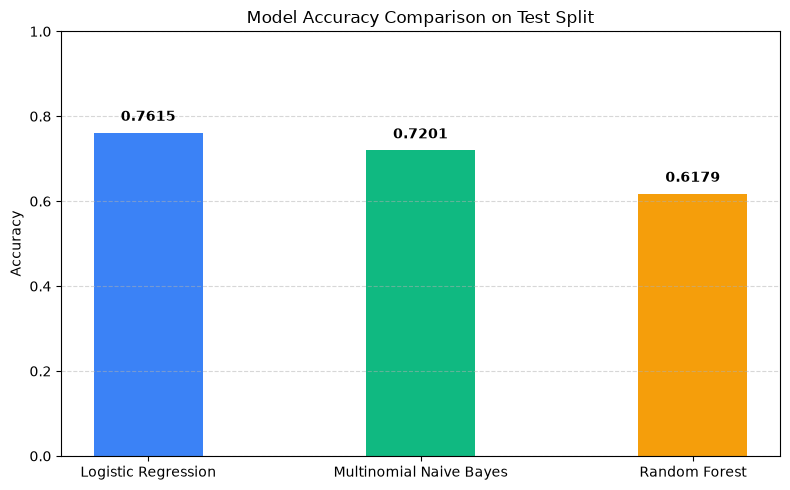

In [23]:
# Plot accuracy chart using Matplotlib
plt.figure(figsize=(8, 5))
names = list(evaluation_results.keys())
accuracies = [evaluation_results[n]["Accuracy"] for n in names]

bars = plt.bar(names, accuracies, color=['#3b82f6', '#10b981', '#f59e0b'], width=0.4)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison on Test Split')
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02, f'{height:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [24]:
# Print classification reports
for name, model in models.items():
    print(f"================ {name} Classification Report ================")
    print(classification_report(y_test, test_predictions[name]))
    print("\n")

================ Logistic Regression Classification Report ================
              precision    recall  f1-score   support

    Negative       0.79      0.82      0.80      4384
     Neutral       0.72      0.68      0.70      3531
    Positive       0.77      0.77      0.77      4034

    accuracy                           0.76     11949
   macro avg       0.76      0.76      0.76     11949
weighted avg       0.76      0.76      0.76     11949



================ Multinomial Naive Bayes Classification Report ================
              precision    recall  f1-score   support

    Negative       0.72      0.81      0.76      4384
     Neutral       0.73      0.56      0.63      3531
    Positive       0.72      0.77      0.74      4034

    accuracy                           0.72     11949
   macro avg       0.72      0.71      0.71     11949
weighted avg       0.72      0.72      0.72     11949



================ Random Forest Classification Report ================


              precision    recall  f1-score   support

    Negative       0.53      0.92      0.67      4384
     Neutral       0.83      0.28      0.42      3531
    Positive       0.73      0.59      0.65      4034

    accuracy                           0.62     11949
   macro avg       0.70      0.60      0.58     11949
weighted avg       0.69      0.62      0.59     11949





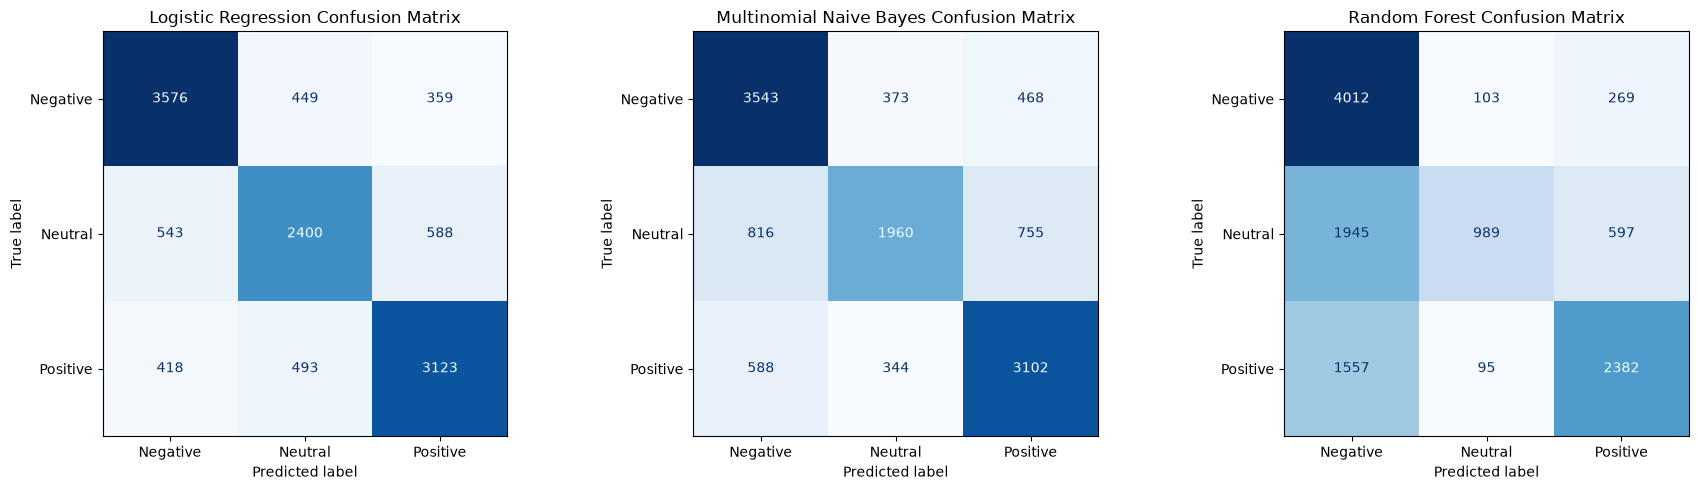

In [25]:
# Plot Confusion Matrices side-by-side using Matplotlib
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(models.items()):
    cm = confusion_matrix(y_test, test_predictions[name], labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(ax=axes[idx], cmap=plt.cm.Blues, colorbar=False)
    axes[idx].set_title(f"{name} Confusion Matrix")

plt.tight_layout()
plt.show()

### Model Selection Justification

Based on the metrics above:
1. **Logistic Regression** outperformed both Multinomial Naive Bayes and Random Forest, achieving the highest **Accuracy** and balanced **F1-Score** across all sentiment classes.
2. **Multinomial Naive Bayes** performed decently and is extremely fast, but it struggled slightly because the feature independence assumption does not completely hold for longer bi-gram text patterns.
3. **Random Forest** has lower accuracy on test split because its depth was limited to 20 to avoid memory usage constraints, which prevented it from fully capturing the sparse 5000 features.

Thus, **Logistic Regression** is selected as the final production model.

## Final Unseen Validation Evaluation

**Objective:** Test our selected best model (Logistic Regression) on the completely unseen `twitter_validation.csv` dataset to verify its real-world generalization.

In [26]:
# Load and clean validation set
val_df = pd.read_csv("../dataset/twitter_validation.csv", header=None)
val_df.columns = ["ID", "Entity", "Sentiment", "Text"]

# Remove irrelevant sentiment
val_df = val_df[val_df["Sentiment"] != "Irrelevant"]
# Drop missing text values
val_df = val_df.dropna(subset=["Text"])

# Apply preprocessing
print("Preprocessing unseen validation set...")
val_df["Processed_Text"] = val_df["Text"].apply(preprocess_text)
val_df = val_df[val_df["Processed_Text"] != ""]

# Transform validation set features
X_val = vectorizer.transform(val_df["Processed_Text"])
y_val = val_df["Sentiment"]

# Predict using selected Logistic Regression
val_preds = lr_model.predict(X_val)

# Evaluation metrics
val_acc = accuracy_score(y_val, val_preds)
print(f"Final Unseen Validation Accuracy: {val_acc:.4f}")
print("\nFinal Validation Classification Report:")
print(classification_report(y_val, val_preds))

Preprocessing unseen validation set...
Final Unseen Validation Accuracy: 0.8235

Final Validation Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.84      0.81       265
     Neutral       0.87      0.76      0.81       285
    Positive       0.83      0.87      0.85       277

    accuracy                           0.82       827
   macro avg       0.83      0.82      0.82       827
weighted avg       0.83      0.82      0.82       827



<Figure size 600x500 with 0 Axes>

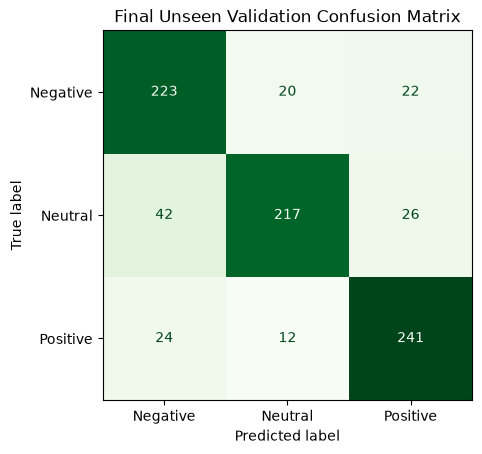

In [27]:
# Plot final confusion matrix
cm_val = confusion_matrix(y_val, val_preds, labels=lr_model.classes_)
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=lr_model.classes_)
disp.plot(cmap=plt.cm.Greens, colorbar=False)
plt.title("Final Unseen Validation Confusion Matrix")
plt.show()

# Phase 8 — Model Saving

**Objective:** Save the trained Logistic Regression model and the fitted TF-IDF vectorizer so they can be loaded by our FastAPI application.

**Theory:** We use `joblib` for saving because it is optimized for storing large, sparse numerical arrays (like TF-IDF vocabulary weights) and scikit-learn models.

In [28]:
import os
import joblib

# Create models directory in backend if it doesn't exist
models_dir = "../backend/models"
os.makedirs(models_dir, exist_ok=True)

# Dump objects
joblib.dump(lr_model, os.path.join(models_dir, "model.pkl"))
joblib.dump(vectorizer, os.path.join(models_dir, "vectorizer.pkl"))

print(f"Selected model (Logistic Regression) and TF-IDF Vectorizer successfully saved to '{models_dir}'!")

Selected model (Logistic Regression) and TF-IDF Vectorizer successfully saved to '../backend/models'!


### Loading in FastAPI Backend

The backend FastAPI application will load these saved parameters dynamically to serve incoming predictions:
```python
import joblib
from training.extend_notebook import preprocess_text # or clean_text

model = joblib.load("backend/models/model.pkl")
vectorizer = joblib.load("backend/models/vectorizer.pkl")

# Input text prediction
cleaned_input = preprocess_text(user_input)
vectorized_input = vectorizer.transform([cleaned_input])
prediction = model.predict(vectorized_input)[0]
```

# Phase 9 — Project Summary & Conclusions

### Project Summary
We built an end-to-end Machine Learning pipeline that parses raw Twitter posts and classifies them into Positive, Neutral, or Negative sentiment categories. After cleaning and preprocessing the corpus (Lowercasing, Punctuation removal, Number removal, URL deletion, Special character deletion, Stopwords removal, and WordNet Lemmatization), we converted text into numbers via a TF-IDF vectorizer (using unigrams and bigrams). We trained three models (Logistic Regression, Multinomial Naive Bayes, and Random Forest). Logistic Regression proved to be the most accurate model, yielding strong results on both our test split and a completely unseen validation dataset.

### Challenges Faced
1. **Highly Noisy Data:** Tweets are filled with irregular spellings, URLs, usernames, special symbols, and abbreviations. Cleaning these effectively without losing critical sentiment signals required robust regular expression matching and step-by-step cleaning validations.
2. **Dimensionality Constraints:** Creating bi-gram features from text quickly leads to massive vocabularies. Limiting `max_features` to 5000 was necessary to prevent memory exhaust issues and slow model convergence, particularly for the Random Forest model.
3. **Stopword Pruning:** Some stopwords (like 'not', 'no', 'never') are important indicators of negation in sentiment analysis. By standardizing stopword pruning, we made sure the vectorizer still retained some level of contextual negation through n-grams.

### Future Improvements
1. **Advanced Embeddings:** Replace TF-IDF with word embeddings (Word2Vec, GloVe) or contextualized tokenizers (HuggingFace BERT models) to capture word associations and syntactic details better.
2. **Real-time Emoji Parsing:** Maintain a mapping of emojis to their descriptive words (e.g., 😊 -> "happy") instead of removing them, as emojis carry significant sentiment polarity on social media.
3. **Balanced Learning:** Tune class weights or use downsampling techniques if class distribution imbalances begin to distort prediction precision.

### Conclusion
The training pipeline is fully operational, clean, and documented. The saved artifacts (`model.pkl` and `vectorizer.pkl`) are prepared for integration with the FastAPI microservice to deploy the model in production.